In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from segmentflow import segment, view
import skimage as ski

In [2]:
user = (
    'cgusb' if 'cgusb' in [f.stem for f in Path(r"C:\Users").iterdir()]
    else 'gusb'
)
img_dir = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    fr'\prill_1_0.25-scale_segmented\prill_1_0.25-scale_labeled_voxels'
)
imgs = segment.load_images(img_dir, file_suffix='.tif')

Loading images...
--> Images loaded as 3D array:  (498, 508, 496)


In [12]:
factor = 2
nslices, nrows, ncols = imgs.shape
vol_nslices, vol_nrows, vol_ncols = np.array([nslices, nrows, ncols]) // factor
# vol_nslices, vol_nrows, vol_ncols
ellip = ski.draw.ellipsoid(vol_ncols//2, vol_nrows//2, vol_nslices//2)
print(ellip.shape)
slice_offset = np.random.randint(0, nslices)
row_offset = np.random.randint(0, nrows)
col_offset = np.random.randint(0, ncols)
print(slice_offset, row_offset, col_offset)

(251, 257, 251)
73 506 170


--> Plotting images: [  0  62 125 187 250]


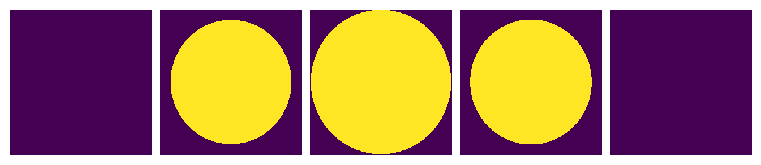

In [14]:
fig, ax = view.vol_slices(ellip, nslices=5)

In [17]:
mask = np.zeros_like(imgs)
mask[
    # nrows-row_offset:nrows,
    # ncols-col_offset:ncols,
    # nslices-slice_offset:nslices
    row_offset:nrows-row_offset,
    col_offset:ncols-col_offset,
    slice_offset:nslices-slice_offset
].shape

(0, 156, 352)